In [85]:
import pandas as pd

In [86]:
df = pd.read_csv("../../data_new/metadata.csv")

In [87]:
df

,id,mask,bg,cso,age,sex,hyp,wmh,isl,lac,bld,bg_derivative,cso_derivative
0,MSSA028,n,4.0,2.0,85.0,F,1.0,101928.515625,1.0,NaN,1.0,3.0,2.0
1,MSSA032,n,1.0,3.0,73.0,M,1.0,58524.609375,1.0,NaN,NaN,1.0,3.0
2,MSSA033,n,1.0,1.0,67.0,M,1.0,17437.500000,1.0,NaN,NaN,1.0,1.0
3,MSSA034,n,1.0,1.0,68.0,F,0.0,18791.015625,1.0,NaN,0.0,1.0,1.0
4,MSSA035,n,2.0,3.0,57.0,M,0.0,19908.899315,1.0,NaN,NaN,2.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1247,VALDO1_211,y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1248,VALDO1_219,y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1249,VALDO1_223,y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1250,VALDO1_224,y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
# add a new column called dataset which is the first 4 characters of the id column
df["dataset"] = df["id"].str[:4]

# split dataframe into rows which have an entry for "bg" and those which have nan
df_scores = df[df["bg"].notna()]
df_noscores = df[df["bg"].isna()]

# split dataset with scores into 70:10:20 train:val:test splits, stratified by bg_derivative, cso_derivative
from sklearn.model_selection import train_test_split
train_val, test = train_test_split(
    df_scores, test_size=0.2, random_state=42, stratify=df_scores[["bg_derivative", "cso_derivative"]]
)
train, val = train_test_split(
    train_val, test_size=0.125, random_state=42, stratify=train_val[["bg_derivative", "cso_derivative"]]
)   

# print number of samples from each dataset in each split
print("Train:")
print(train["dataset"].value_counts())
print("\nVal:")
print(val["dataset"].value_counts())
print("\nTest:")
print(test["dataset"].value_counts())

Train:
dataset
LBC3    463
MSSB    177
MSS3    160
MSSA     67
Name: count, dtype: int64

Val:
dataset
LBC3    71
MSS3    28
MSSB    17
MSSA     8
Name: count, dtype: int64

Test:
dataset
LBC3    128
MSSB     62
MSS3     40
MSSA     18
Name: count, dtype: int64


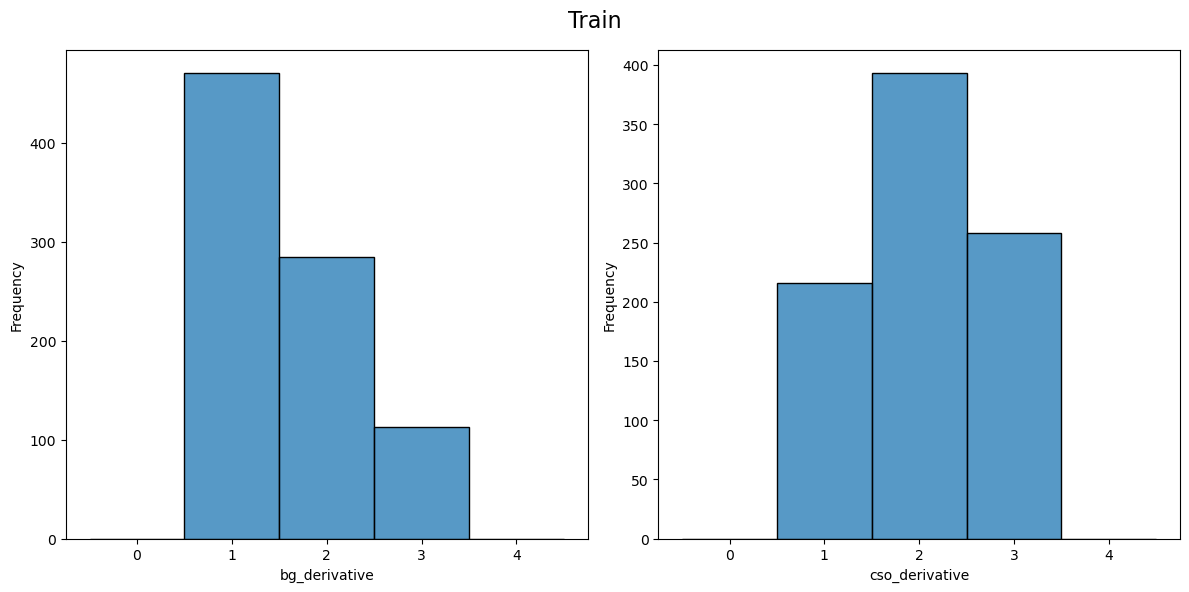

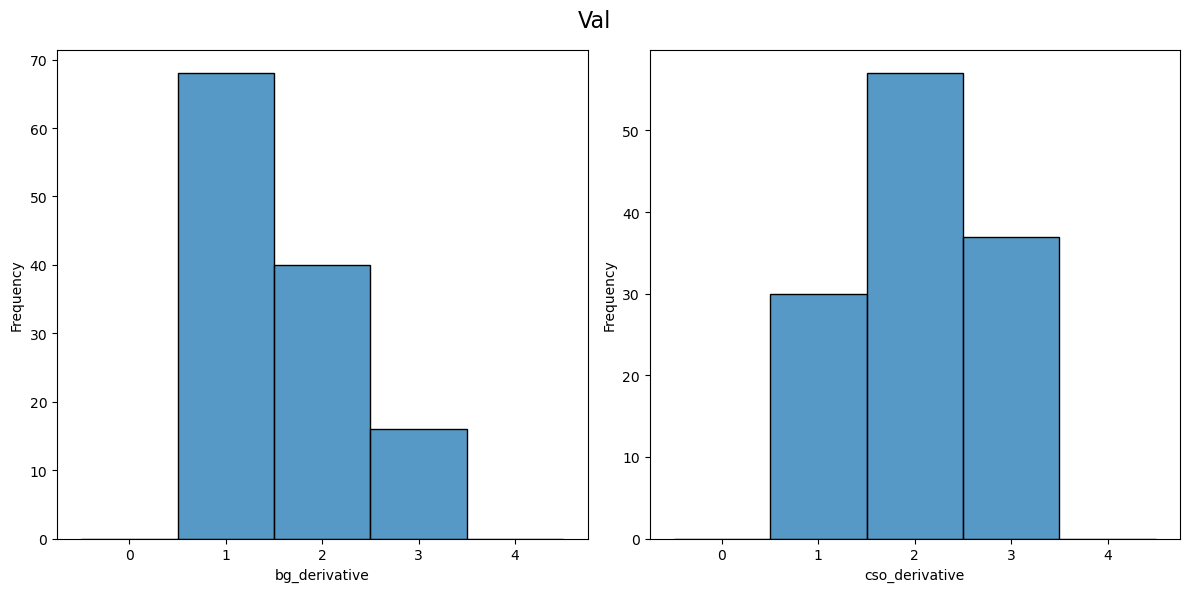

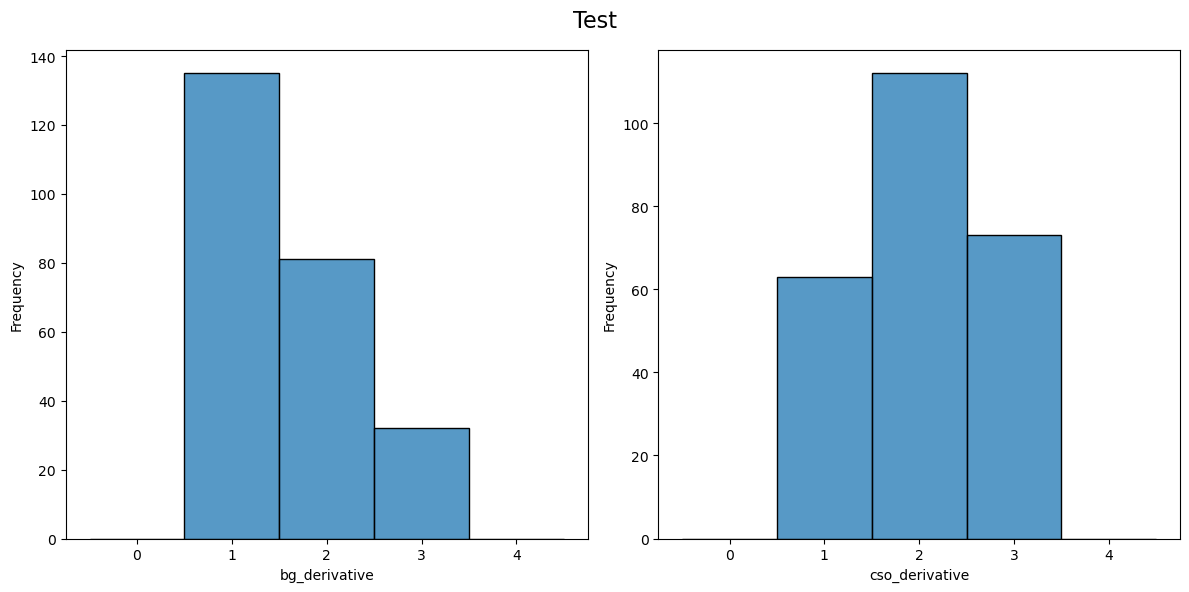

In [89]:
# plot histograms of bg_derivative and cso_derivative for each split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_histograms(df, title, derivative=False):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(title, fontsize=16)
    
    s = "_derivative" if derivative else ""
    
    # Plot histogram for bg
    sns.histplot(df[f"bg{s}"], bins=np.arange(0, 6) - 0.5, kde=False, ax=axes[0])
    axes[0].set_xlabel(f"bg{s}")
    axes[0].set_ylabel("Frequency")
    axes[0].set_xticks(range(5))
    
    # Plot histogram for cso
    sns.histplot(df[f"cso{s}"], bins=np.arange(0, 6) - 0.5, kde=False, ax=axes[1])
    axes[1].set_xlabel(f"cso{s}")
    axes[1].set_ylabel("Frequency")
    axes[1].set_xticks(range(5))
    
    plt.tight_layout()
    plt.show()

plot_histograms(train, "Train", True)
plot_histograms(val, "Val", True)
plot_histograms(test, "Test", True)

In [90]:
# Add the columns without scores to the training set
train = pd.concat([train, df_noscores], ignore_index=True)

In [91]:
# Check that all items in the test set have age and sex information
print("Test set items with missing age:", test["age"].isna().sum())
print("Test set items with missing sex:", test["sex"].isna().sum())

Test set items with missing age: 0
Test set items with missing sex: 0


In [ ]:
# Remove the dataset column
train = train.drop(columns=["dataset"])
val = val.drop(columns=["dataset"])
test = test.drop(columns=["dataset"])

# fill na with N/A
train = train.fillna("N/A")
val = val.fillna("N/A")
test = test.fillna("N/A")

# # Save the splits to csv files
# train.to_csv("../../data_new/splits/train.csv", index=False)
# val.to_csv("../../data_new/splits/val.csv", index=False)
# test.to_csv("../../data_new/splits/test.csv", index=False)